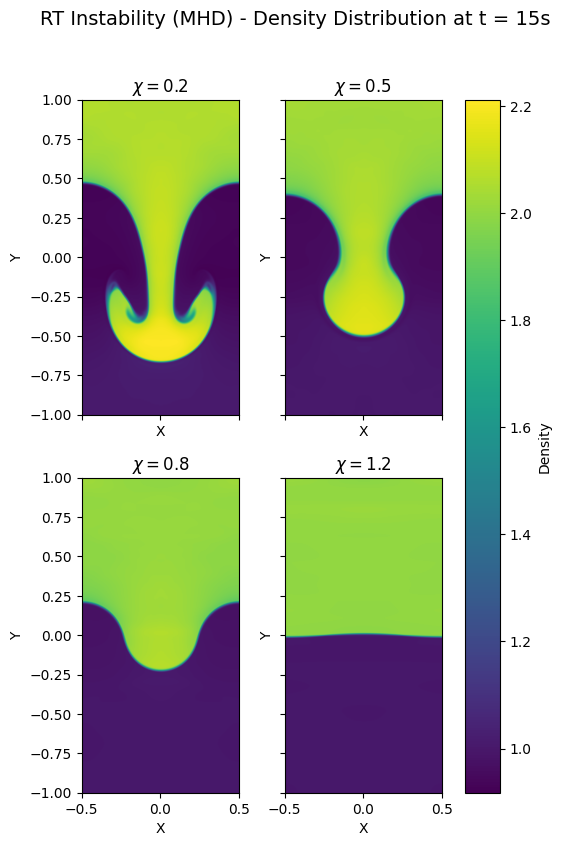

In [12]:
# Density plots for Rayleigh-Taylor Instability in MHD
import numpy as np
import matplotlib.pyplot as plt

files = ['0.2', '0.5', '0.8', '1.2']
nx, ny = 256, 512

data_list = []
for f in files:
    data = np.fromfile(f"{f}-rho.0015.dbl", dtype=np.float64).reshape((nx, ny), order='F')
    data_list.append(data)

vmin = min(d.min() for d in data_list)
vmax = max(d.max() for d in data_list)

fig, axes = plt.subplots(2, 2, figsize=(6, 9))
fig.suptitle("RT Instability (MHD) - Density Distribution at t = 15s", fontsize=14)

for ax, f, Z in zip(axes.flat, files, data_list):
    im = ax.imshow(Z.T, origin='lower', aspect=1, cmap='viridis', vmin=vmin, vmax=vmax, extent=[-0.5, 0.5, -1, 1])
    ax.label_outer()
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(rf"$\chi = {f}$")

cbar = fig.colorbar(im, ax=axes.ravel().tolist(), label='Density')

plt.savefig("../RT_MHD_rho.png", dpi=300)
plt.show()

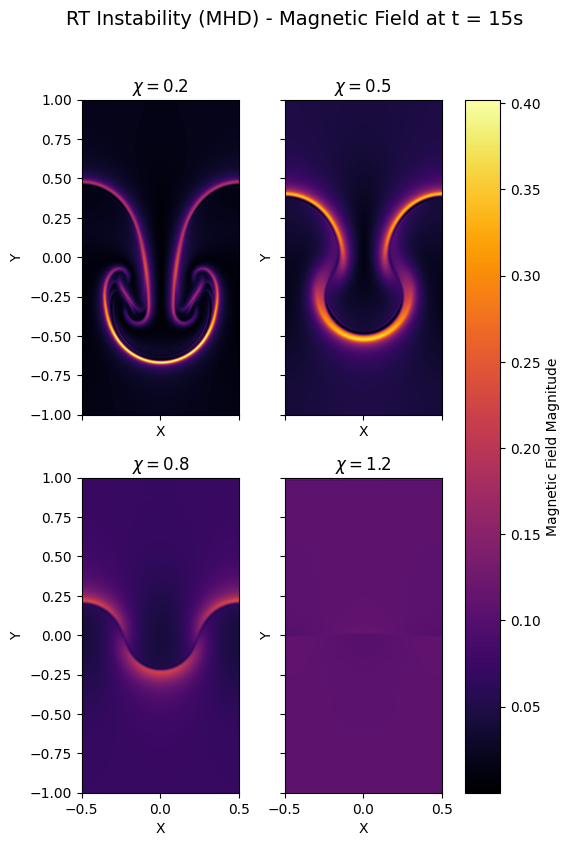

In [11]:
# Magnetic Field plots for Rayleigh-Taylor Instability in MHD
import numpy as np
import matplotlib.pyplot as plt

files = ['0.2', '0.5', '0.8', '1.2']
nx, ny = 256, 512

B_list = []

# Load magnetic field components and compute magnitude
for f in files:
    Bx1 = np.fromfile(f"{f}-Bx1.0015.dbl", dtype=np.float64).reshape((nx, ny), order='F')
    Bx2 = np.fromfile(f"{f}-Bx2.0015.dbl", dtype=np.float64).reshape((nx, ny), order='F')
    Bx3 = np.fromfile(f"{f}-Bx3.0015.dbl", dtype=np.float64).reshape((nx, ny), order='F')
    
    B_mag = np.sqrt(Bx1**2 + Bx2**2 + Bx3**2)
    B_list.append(B_mag)

# Determine global min and max for consistent color scale
vmin = min(B.min() for B in B_list)
vmax = max(B.max() for B in B_list)

# Create 2x3 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(6, 9), sharex=True, sharey=True)
fig.suptitle("RT Instability (MHD) - Magnetic Field at t = 15s", fontsize=14)

for ax, f, B in zip(axes.flat, files, B_list):
    im = ax.imshow(B.T, origin='lower', aspect=1, cmap='inferno', vmin=vmin, vmax=vmax, extent=[-0.5, 0.5, -1, 1])
    ax.label_outer()
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_title(rf"$\chi = {f}$")

# Shared colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), label='Magnetic Field Magnitude')

plt.savefig("../RT_MHD_B.png", dpi=300)
plt.show()